In [1]:
!pip install -q "gymnasium[classic-control]" "stable-baselines3[extra]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 6.2 MB/s eta 0:00:00


Celda de configuraciones:

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import torch

from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy

SEED = 42
N_EPISODES_EVAL = 30
TOTAL_TIMESTEPS = 60_000

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

os.makedirs("resultados_cartpole", exist_ok=True)
os.makedirs("resultados_cartpole/modelos", exist_ok=True)
os.makedirs("resultados_cartpole/evaluaciones", exist_ok=True)
os.makedirs("resultados_cartpole/videos", exist_ok=True)

print("Gymnasium:", gym.__version__)
print("PyTorch:", torch.__version__)
print("Dispositivo:", "GPU" if torch.cuda.is_available() else "CPU")

Gymnasium: 1.3.0
PyTorch: 2.11.0+cu128
Dispositivo: GPU


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
env_info = gym.make("CartPole-v1")

print("Espacio de acciones:", env_info.action_space)
print("Espacio de observaciones:", env_info.observation_space)
print("Máximo de pasos:", env_info.spec.max_episode_steps)

env_info.close()

Espacio de acciones: Discrete(2)
Espacio de observaciones: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Máximo de pasos: 500


In [4]:
def evaluar_politica_aleatoria(n_episodios=30, seed=42):
    recompensas = []

    for episodio in range(n_episodios):
        env = gym.make("CartPole-v1")
        observacion, info = env.reset(seed=seed + episodio)

        recompensa_total = 0
        terminado = False
        truncado = False

        while not (terminado or truncado):
            accion = env.action_space.sample()

            observacion, recompensa, terminado, truncado, info = env.step(accion)
            recompensa_total += recompensa

        recompensas.append(recompensa_total)
        env.close()

    return np.array(recompensas)

In [5]:
recompensas_random = evaluar_politica_aleatoria(
    n_episodios=N_EPISODES_EVAL,
    seed=SEED
)

print("POLÍTICA ALEATORIA")
print("-------------------")
print(f"Media: {recompensas_random.mean():.2f}")
print(f"Desviación típica: {recompensas_random.std():.2f}")
print(f"Mínimo: {recompensas_random.min():.0f}")
print(f"Máximo: {recompensas_random.max():.0f}")
print(f"Episodios de 500 pasos: {(recompensas_random == 500).sum()}/{N_EPISODES_EVAL}")

POLÍTICA ALEATORIA
-------------------
Media: 20.03
Desviación típica: 7.74
Mínimo: 10
Máximo: 48
Episodios de 500 pasos: 0/30


In [6]:
entorno_entrenamiento = make_vec_env(
    "CartPole-v1",
    n_envs=1,
    seed=SEED,
    monitor_dir="resultados_cartpole"
)

entorno_evaluacion = make_vec_env(
    "CartPole-v1",
    n_envs=1,
    seed=SEED + 1000
)

In [7]:
callback_evaluacion = EvalCallback(
    entorno_evaluacion,
    best_model_save_path="resultados_cartpole/modelos",
    log_path="resultados_cartpole/evaluaciones",
    eval_freq=1_000,
    n_eval_episodes=10,
    deterministic=True,
    render=False,
    verbose=1
)

In [8]:
modelo = DQN(
    policy="MlpPolicy",
    env=entorno_entrenamiento,

    learning_rate=1e-3,
    buffer_size=50_000,
    learning_starts=1_000,
    batch_size=64,
    gamma=0.99,

    train_freq=4,
    gradient_steps=1,
    target_update_interval=500,

    exploration_initial_eps=1.0,
    exploration_fraction=0.25,
    exploration_final_eps=0.02,

    policy_kwargs=dict(net_arch=[64, 64]),

    seed=SEED,
    verbose=1,
    device="cpu"
)

Using cpu device


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
modelo.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=callback_evaluacion,
    progress_bar=True
)

modelo.save("resultados_cartpole/modelos/dqn_cartpole_final")

entorno_entrenamiento.close()
entorno_evaluacion.close()

print("Entrenamiento finalizado y modelo guardado.")

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 23       |
|    ep_rew_mean      | 23       |
|    exploration_rate | 0.994    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1877     |
|    time_elapsed     | 0        |
|    total_timesteps  | 92       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 24.9     |
|    ep_rew_mean      | 24.9     |
|    exploration_rate | 0.987    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 3128     |
|    time_elapsed     | 0        |
|    total_timesteps  | 199      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 26.8     |
|    ep_rew_mean      | 26.8     |
|    exploration_rate | 0.979    |
| time/               |          |
|    episodes       

Eval num_timesteps=1000, episode_reward=9.50 +/- 0.50

Episode length: 9.50 +/- 0.50

...

----------------------------------
| eval/               |          |
|    mean_ep_length   | 281      |
|    mean_reward      | 281      |
| rollout/            |          |
|    exploration_rate | 0.02     |
| time/               |          |
|    total_timesteps  | 59000    |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.0235   |
|    n_updates        | 14499    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 152      |
|    ep_rew_mean      | 152      |
|    exploration_rate | 0.02     |
| time/               |          |
|    episodes         | 620      |
|    fps              | 574      |
|    time_elapsed     | 102      |
|    total_timesteps  | 59142    |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.0376   |
|    n_updates        | 14535    |
----------------------------------
--------------------

Eval num_timesteps=60000, episode_reward=209.70 +/- 10.04

Episode length: 209.70 +/- 10.04

----------------------------------
| eval/               |          |
|    mean_ep_length   | 210      |
|    mean_reward      | 210      |
| rollout/            |          |
|    exploration_rate | 0.02     |
| time/               |          |
|    total_timesteps  | 60000    |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.0161   |
|    n_updates        | 14749    |
----------------------------------


Entrenamiento finalizado y modelo guardado.


In [10]:
from stable_baselines3 import DQN

ruta_mejor_modelo = "resultados_cartpole/modelos/best_model"
ruta_modelo_final = "resultados_cartpole/modelos/dqn_cartpole_final"

modelo_mejor = DQN.load(ruta_mejor_modelo)
modelo_final = DQN.load(ruta_modelo_final)

print("Modelos cargados correctamente.")

Modelos cargados correctamente.


In [11]:
def evaluar_modelo(modelo, nombre, n_episodios=30, seed=1000):
    resultados = []
    env = gym.make("CartPole-v1")

    for episodio in range(n_episodios):
        observacion, info = env.reset(seed=seed + episodio)

        recompensa_total = 0
        pasos = 0
        terminado = False
        truncado = False

        while not (terminado or truncado):
            accion, _ = modelo.predict(
                observacion,
                deterministic=True
            )

            accion = int(np.asarray(accion).item())

            observacion, recompensa, terminado, truncado, info = env.step(
                accion
            )

            recompensa_total += recompensa
            pasos += 1

        resultados.append({
            "modelo": nombre,
            "episodio": episodio + 1,
            "recompensa": recompensa_total,
            "pasos": pasos,
            "alcanza_500": pasos == 500
        })

    env.close()

    return pd.DataFrame(resultados)

In [12]:
resultados_mejor = evaluar_modelo(
    modelo_mejor,
    nombre="Mejor modelo",
    n_episodios=N_EPISODES_EVAL,
    seed=1000
)

resultados_final = evaluar_modelo(
    modelo_final,
    nombre="Modelo final",
    n_episodios=N_EPISODES_EVAL,
    seed=1000
)

resultados_dqn = pd.concat(
    [resultados_mejor, resultados_final],
    ignore_index=True
)

resultados_dqn.head()

,modelo,episodio,recompensa,pasos,alcanza_500
0,Mejor modelo,1,500.0,500,True
1,Mejor modelo,2,500.0,500,True
2,Mejor modelo,3,500.0,500,True
3,Mejor modelo,4,500.0,500,True
4,Mejor modelo,5,500.0,500,True


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:
def evaluar_aleatoria_reproducible(
    n_episodios=30,
    seed=1000
):
    resultados = []
    env = gym.make("CartPole-v1")

    for episodio in range(n_episodios):
        semilla_episodio = seed + episodio

        # Inicializa el entorno con el mismo estado inicial
        # utilizado para evaluar los modelos DQN.
        observacion, info = env.reset(
            seed=semilla_episodio
        )

        # Hace reproducible la selección de acciones aleatorias.
        env.action_space.seed(semilla_episodio)

        recompensa_total = 0
        pasos = 0
        terminado = False
        truncado = False

        while not (terminado or truncado):
            accion = env.action_space.sample()

            observacion, recompensa, terminado, truncado, info = env.step(
                accion
            )

            recompensa_total += recompensa
            pasos += 1

        resultados.append({
            "modelo": "Política aleatoria",
            "episodio": episodio + 1,
            "recompensa": recompensa_total,
            "pasos": pasos,
            "alcanza_500": pasos == 500
        })

    env.close()

    return pd.DataFrame(resultados)

In [14]:
resultados_random = evaluar_aleatoria_reproducible(
    n_episodios=N_EPISODES_EVAL,
    seed=1000
)

resultados_random.head()

,modelo,episodio,recompensa,pasos,alcanza_500
0,Política aleatoria,1,38.0,38,False
1,Política aleatoria,2,15.0,15,False
2,Política aleatoria,3,25.0,25,False
3,Política aleatoria,4,19.0,19,False
4,Política aleatoria,5,18.0,18,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [15]:
resumen_dqn = (
    resultados_dqn
    .groupby("modelo")
    .agg(
        recompensa_media=("recompensa", "mean"),
        desviacion_tipica=("recompensa", "std"),
        recompensa_minima=("recompensa", "min"),
        recompensa_maxima=("recompensa", "max"),
        episodios_500=("alcanza_500", "sum")
    )
    .reset_index()
)

resumen_dqn["porcentaje_exito"] = (
    100 * resumen_dqn["episodios_500"] / N_EPISODES_EVAL
)

resumen_dqn = resumen_dqn.round(2)

resumen_dqn

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,modelo,recompensa_media,desviacion_tipica,recompensa_minima,recompensa_maxima,episodios_500,porcentaje_exito
0,Mejor modelo,500.00,0.0,500.0,500.0,30,100.0
1,Modelo final,227.13,11.9,208.0,256.0,0,0.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [16]:
resumen_random = pd.DataFrame([{
    "modelo": "Política aleatoria",
    "recompensa_media": resultados_random["recompensa"].mean(),
    "desviacion_tipica": resultados_random["recompensa"].std(),
    "recompensa_minima": resultados_random["recompensa"].min(),
    "recompensa_maxima": resultados_random["recompensa"].max(),
    "episodios_500": int(resultados_random["alcanza_500"].sum()),
    "porcentaje_exito": 100 * resultados_random["alcanza_500"].mean()
}])

resumen_completo = pd.concat(
    [resumen_random, resumen_dqn],
    ignore_index=True
).round(2)

resumen_completo

,modelo,recompensa_media,desviacion_tipica,recompensa_minima,recompensa_maxima,episodios_500,porcentaje_exito
0,Política aleatoria,21.07,8.79,10.0,42.0,0,0.0
1,Mejor modelo,500.00,0.00,500.0,500.0,30,100.0
2,Modelo final,227.13,11.90,208.0,256.0,0,0.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
resumen_dqn.to_csv(
    "resultados_cartpole/resumen_evaluacion_dqn.csv",
    index=False
)

resultados_dqn.to_csv(
    "resultados_cartpole/resultados_episodios_dqn.csv",
    index=False
)

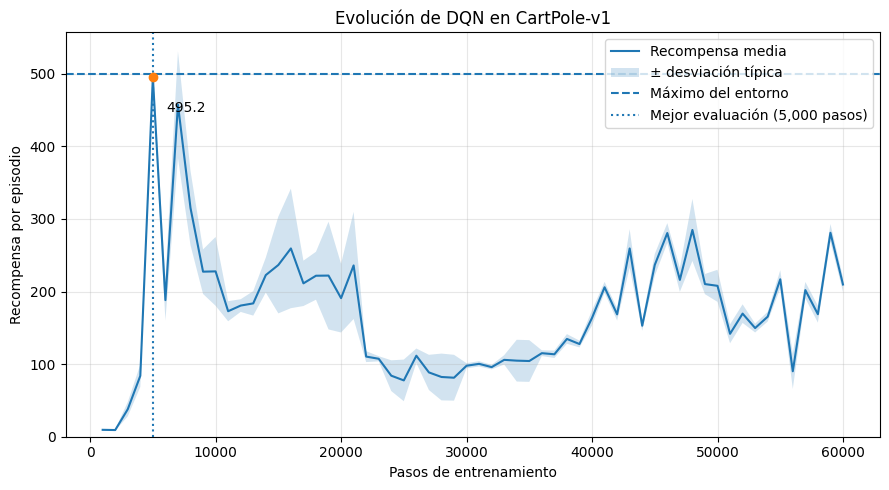

In [18]:
import numpy as np # Import numpy if not already imported

# Load evaluation data
evaluation_data = np.load("resultados_cartpole/evaluaciones/evaluations.npz")
timesteps = evaluation_data["timesteps"]
raw_rewards = evaluation_data["results"]

# Calculate mean and standard deviation from raw_rewards
media_recompensas = np.mean(raw_rewards, axis=1)
desviacion_recompensas = np.std(raw_rewards, axis=1)

# Find the best evaluation point
indice_mejor = np.argmax(media_recompensas)
paso_mejor = timesteps[indice_mejor]
recompensa_mejor = media_recompensas[indice_mejor]

plt.figure(figsize=(9, 5))

plt.plot(
    timesteps,
    media_recompensas,
    label="Recompensa media"
)

plt.fill_between(
    timesteps,
    media_recompensas - desviacion_recompensas,
    media_recompensas + desviacion_recompensas,
    alpha=0.2,
    label="± desviación típica"
)

plt.axhline(
    y=500,
    linestyle="--",
    label="Máximo del entorno"
)

plt.axvline(
    x=paso_mejor,
    linestyle=":",
    label=f"Mejor evaluación ({paso_mejor:,} pasos)"
)

plt.scatter(
    paso_mejor,
    recompensa_mejor,
    zorder=3
)

plt.annotate(
    f"{recompensa_mejor:.1f}",
    xy=(paso_mejor, recompensa_mejor),
    xytext=(10, -25),
    textcoords="offset points"
)

plt.xlabel("Pasos de entrenamiento")
plt.ylabel("Recompensa por episodio")
plt.title("Evolución de DQN en CartPole-v1")
plt.ylim(bottom=0)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "resultados_cartpole/curva_entrenamiento_cartpole.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
fila_ganadora = resumen_dqn.sort_values(
    by=[
        "recompensa_media",
        "recompensa_minima",
        "porcentaje_exito"
    ],
    ascending=False
).iloc[0]

nombre_ganador = fila_ganadora["modelo"]

if nombre_ganador == "Mejor modelo":
    modelo_seleccionado = modelo_mejor
else:
    modelo_seleccionado = modelo_final

print("Modelo seleccionado:", nombre_ganador)
print(f"Recompensa media: {fila_ganadora['recompensa_media']}")
print(f"Recompensa mínima: {fila_ganadora['recompensa_minima']}")
print(f"Éxito: {fila_ganadora['porcentaje_exito']} %")

Modelo seleccionado: Mejor modelo
Recompensa media: 500.0
Recompensa mínima: 500.0
Éxito: 100.0 %


In [20]:
import glob
from gymnasium.wrappers import RecordVideo
from IPython.display import Video, display

entorno_video = gym.make(
    "CartPole-v1",
    render_mode="rgb_array"
)

entorno_video = RecordVideo(
    entorno_video,
    video_folder="resultados_cartpole/videos",
    episode_trigger=lambda episodio: True,
    name_prefix="dqn_cartpole_mejor"
)

observacion, info = entorno_video.reset(seed=1000)

terminado = False
truncado = False
recompensa_total = 0
pasos = 0

while not (terminado or truncado):
    accion, _ = modelo_mejor.predict(
        observacion,
        deterministic=True
    )

    accion = int(np.asarray(accion).item())

    observacion, recompensa, terminado, truncado, info = entorno_video.step(
        accion
    )

    recompensa_total += recompensa
    pasos += 1

entorno_video.close()

print(f"Pasos completados: {pasos}")
print(f"Recompensa total: {recompensa_total}")

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/resultados_cartpole/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Pasos completados: 500
Recompensa total: 500.0


In [21]:
videos = glob.glob(
    "resultados_cartpole/videos/*.mp4"
)

display(Video(videos[-1], embed=True))

In [28]:
import glob
import numpy as np
import gymnasium as gym

from gymnasium.wrappers import RecordVideo
from IPython.display import Video, display

# Crear el entorno con renderizado
entorno_video_random = gym.make(
    "CartPole-v1",
    render_mode="rgb_array"
)

# Grabar únicamente el primer episodio
entorno_video_random = RecordVideo(
    entorno_video_random,
    video_folder="resultados_cartpole/videos",
    episode_trigger=lambda episodio: episodio == 0,
    name_prefix="cartpole_aleatorio"
)

# Usamos la misma semilla inicial que con el mejor DQN
SEMILLA_VIDEO = 1000

observacion, info = entorno_video_random.reset(
    seed=SEMILLA_VIDEO
)

# Hace reproducible la secuencia de acciones aleatorias
entorno_video_random.action_space.seed(
    SEMILLA_VIDEO
)

terminado = False
truncado = False
recompensa_total = 0
pasos = 0

while not (terminado or truncado):

    # La política aleatoria no utiliza la observación
    accion = entorno_video_random.action_space.sample()

    observacion, recompensa, terminado, truncado, info = (
        entorno_video_random.step(accion)
    )

    recompensa_total += recompensa
    pasos += 1

angulo_final_grados = np.degrees(observacion[2])
posicion_final = observacion[0]

print(f"Ángulo final: {angulo_final_grados:.2f} grados")
print(f"Posición final del carro: {posicion_final:.2f}")
print(f"Terminado: {terminado}")
print(f"Truncado: {truncado}")

entorno_video_random.close()

print(f"Pasos completados: {pasos}")
print(f"Recompensa total: {recompensa_total}")

Ángulo final: -13.17 grados
Posición final del carro: 0.02
Terminado: True
Truncado: False
Pasos completados: 38
Recompensa total: 38.0


In [23]:
videos_random = sorted(
    glob.glob(
        "resultados_cartpole/videos/cartpole_aleatorio*.mp4"
    )
)

print("Vídeo generado:", videos_random[-1])

display(
    Video(
        videos_random[-1],
        embed=True
    )
)

Vídeo generado: resultados_cartpole/videos/cartpole_aleatorio-episode-0.mp4


In [ ]:
indice_mejor = np.argmax(media_recompensas)

paso_mejor = timesteps[indice_mejor]
recompensa_mejor = media_recompensas[indice_mejor]
resultados_mejor_evaluacion = raw_rewards[indice_mejor]

print("Mejor evaluación durante el entrenamiento")
print("------------------------------------------")
print(f"Paso de entrenamiento: {paso_mejor}")
print(f"Recompensa media: {recompensa_mejor:.2f}")
print("Recompensas de los episodios:", resultados_mejor_evaluacion)

Mejor evaluación durante el entrenamiento
------------------------------------------
Paso de entrenamiento: 5000
Recompensa media: 495.20
Recompensas de los episodios: [500. 452. 500. 500. 500. 500. 500. 500. 500. 500.]


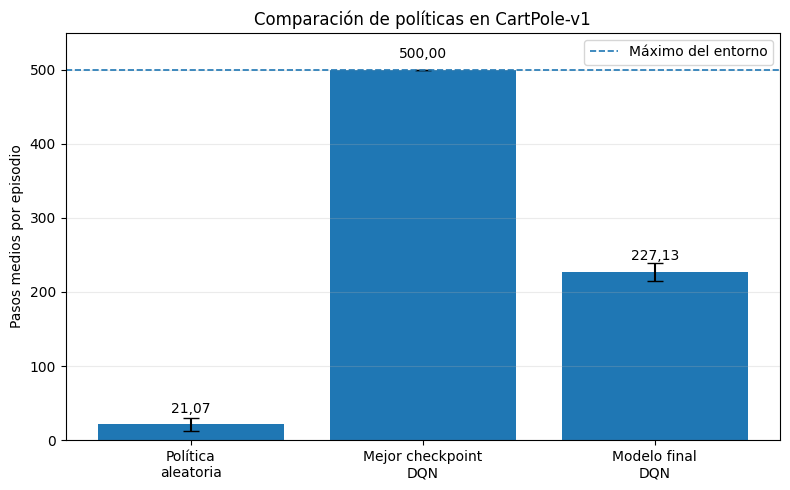

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Carpeta donde se guardará la figura
os.makedirs("resultados_cartpole", exist_ok=True)

# Orden y nombres que aparecerán en la gráfica
orden_modelos = [
    "Política aleatoria",
    "Mejor modelo",
    "Modelo final"
]

etiquetas = [
    "Política\naleatoria",
    "Mejor checkpoint\nDQN",
    "Modelo final\nDQN"
]

# Ordenar el DataFrame para asegurarnos de que las barras
# aparecen en el orden deseado
datos_grafica = (
    resumen_completo
    .set_index("modelo")
    .loc[orden_modelos]
    .reset_index()
)

medias = datos_grafica["recompensa_media"].to_numpy()
desviaciones = datos_grafica["desviacion_tipica"].to_numpy()

posiciones = np.arange(len(etiquetas))

plt.figure(figsize=(8, 5))

barras = plt.bar(
    posiciones,
    medias,
    yerr=desviaciones,
    capsize=6
)

# Máximo posible en CartPole-v1
plt.axhline(
    y=500,
    linestyle="--",
    linewidth=1.2,
    label="Máximo del entorno"
)

plt.xticks(posiciones, etiquetas)
plt.ylabel("Pasos medios por episodio")
plt.title("Comparación de políticas en CartPole-v1")
plt.ylim(0, 550)
plt.grid(axis="y", alpha=0.25)
plt.legend()

# Mostrar el valor exacto encima de cada barra
for barra, media in zip(barras, medias):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 12,
        f"{media:.2f}".replace(".", ","),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "resultados_cartpole/comparacion_politicas_cartpole.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()